<a href="https://colab.research.google.com/github/Lomada-Sahithi/Machine-Learning-Sem-5/blob/main/8_6_Support_Vector_Machines_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import metrics

In [3]:
data = {
    'Word_Frequency': [2, 3, 4, 5, 6, 7, 8, 9, 3, 6],
    'Message_Length': [20, 25, 30, 35, 60, 70, 80, 90, 28, 65],
    'Spam': ['No', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

print(df)

   Word_Frequency  Message_Length Spam
0               2              20   No
1               3              25   No
2               4              30   No
3               5              35   No
4               6              60  Yes
5               7              70  Yes
6               8              80  Yes
7               9              90  Yes
8               3              28   No
9               6              65  Yes


In [4]:
X = df[['Word_Frequency', 'Message_Length']]
y = df['Spam']

print("Input Variables (X):")
print(X)

print("\nTarget Variable (y):")
print(y)

Input Variables (X):
   Word_Frequency  Message_Length
0               2              20
1               3              25
2               4              30
3               5              35
4               6              60
5               7              70
6               8              80
7               9              90
8               3              28
9               6              65

Target Variable (y):
0     No
1     No
2     No
3     No
4    Yes
5    Yes
6    Yes
7    Yes
8     No
9    Yes
Name: Spam, dtype: object


In [5]:
y = y.map({'No': 0, 'Yes': 1})

print("Converted Target Variable (y):")
print(y)

Converted Target Variable (y):
0    0
1    0
2    0
3    0
4    1
5    1
6    1
7    1
8    0
9    1
Name: Spam, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:")
print(X_train)

print("\nTesting data:")
print(X_test)

print("\nTraining target:")
print(y_train)

print("\nTesting target:")
print(y_test)

Training data:
   Word_Frequency  Message_Length
5               7              70
0               2              20
7               9              90
2               4              30
9               6              65
4               6              60
3               5              35
6               8              80

Testing data:
   Word_Frequency  Message_Length
8               3              28
1               3              25

Training target:
5    1
0    0
7    1
2    0
9    1
4    1
3    0
6    1
Name: Spam, dtype: int64

Testing target:
8    0
1    0
Name: Spam, dtype: int64


In [7]:
model = SVC(kernel='linear', random_state=42)

model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [8]:
y_pred = model.predict(X_test)

print("Actual values:")
print(y_test.values)

print("\nPredicted values:")
print(y_pred)

Actual values:
[0 0]

Predicted values:
[0 0]


In [9]:
accuracy = metrics.accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy in percentage:", accuracy * 100, "%")


Accuracy: 1.0
Accuracy in percentage: 100.0 %


In [10]:
confusion_matrix = metrics.confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[2 0]
 [0 0]]


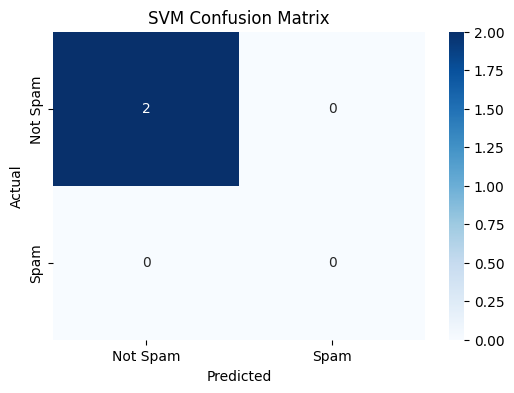

In [11]:
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Spam', 'Spam'],
    yticklabels=['Not Spam', 'Spam']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()

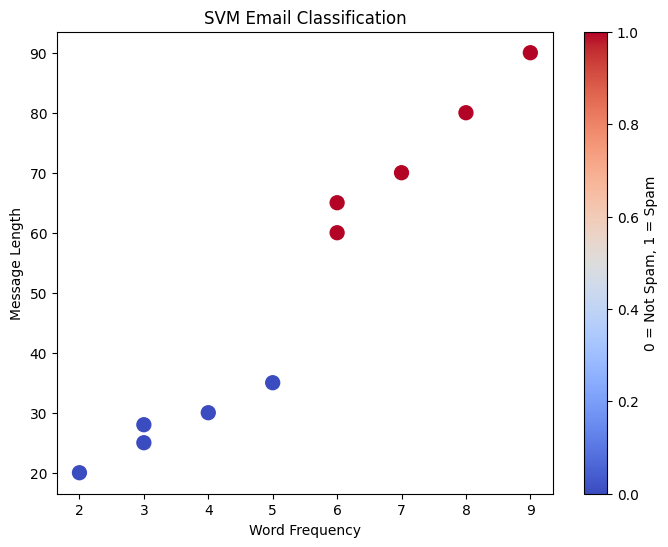

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X['Word_Frequency'],
    X['Message_Length'],
    c=y,
    cmap='coolwarm',
    s=100
)

plt.xlabel('Word Frequency')
plt.ylabel('Message Length')
plt.title('SVM Email Classification')
plt.colorbar(label='0 = Not Spam, 1 = Spam')

plt.show()

In [13]:
precision = metrics.precision_score(y_test, y_pred, zero_division=0)
recall = metrics.recall_score(y_test, y_pred, zero_division=0)
f1 = metrics.f1_score(y_test, y_pred, zero_division=0)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 0.0
Recall: 0.0
F1-Score: 0.0


In [15]:
print("Classification Report:")

print(metrics.classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=['Not Spam', 'Spam'],
    zero_division=0
))

Classification Report:
              precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00         2
        Spam       0.00      0.00      0.00         0

    accuracy                           1.00         2
   macro avg       0.50      0.50      0.50         2
weighted avg       1.00      1.00      1.00         2



In [16]:
new_email = pd.DataFrame({
    'Word_Frequency': [7],
    'Message_Length': [75]
})

prediction = model.predict(new_email)

if prediction[0] == 1:
    print("Prediction: Spam")
else:
    print("Prediction: Not Spam")

Prediction: Spam


In [17]:
print("FINAL RESULTS")
print("-" * 40)

print("Model: Support Vector Machine (SVM)")
print("Input Variables: Word Frequency, Message Length")
print("Target Variable: Spam")

print("\nAccuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

print("\nConfusion Matrix:")
print(confusion_matrix)

print("\nActual Test Values:", y_test.values)
print("Predicted Test Values:", y_pred)

print("\nNew Email Prediction:")
if prediction[0] == 1:
    print("Spam")
else:
    print("Not Spam")

FINAL RESULTS
----------------------------------------
Model: Support Vector Machine (SVM)
Input Variables: Word Frequency, Message Length
Target Variable: Spam

Accuracy: 1.0
Accuracy Percentage: 100.0 %

Confusion Matrix:
[[2 0]
 [0 0]]

Actual Test Values: [0 0]
Predicted Test Values: [0 0]

New Email Prediction:
Spam
